In [37]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv('./H-AIRosettaMP_C_Cpp_Csharp.csv')

df = df.drop(['task_url', 'task_name', 'task_description', 'set'], axis=1)
df.info()

nulls = np.where(pd.isnull(df))
df = df.drop(nulls[0], axis=0)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35075 entries, 0 to 35074
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  35075 non-null  object
 1   code           35069 non-null  object
 2   target         35075 non-null  object
dtypes: object(3)
memory usage: 822.2+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 35069 entries, 0 to 35074
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  35069 non-null  object
 1   code           35069 non-null  object
 2   target         35069 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB


,language_name,code,target
0,cpp,#include <iostream>\n#include <vector>\n#inclu...,Ai_generated
1,cpp,#include <iostream>\n#include <string>\n\nusin...,Ai_generated
2,cpp,#include <iostream>\nusing namespace std;\n\ni...,Ai_generated
3,cpp,/*\n * Arithmetic-Geometric Mean of 1 & 1/sqrt...,Ai_generated
4,cpp,#include <iostream>\n#include <string>\n#inclu...,Ai_generated


In [38]:
lenguajes = df['language_name'].unique()
targets = df['target'].unique()

valores = {
    'language_name': lenguajes,
    'target': targets
}

for column in df.columns:
    if column not in ['code', 'comments']:
        print(column)
        val = valores[column]
        print(f'Valores: {val}')
        df[column] = df[column].replace(val, range(len(val)))

regex_coment = r"//[^\n]*|/\*.*?\*/"
df['comments'] = ""

for i in df.index:
    codigo = df['code'][i]
    match = re.findall(regex_coment, codigo, re.DOTALL)
    rest = re.split(regex_coment, codigo, flags=re.DOTALL)
    if i == 3:
        print(rest)
        print(match)
    df.at[i, 'code'] = ' '.join(rest)
    df.at[i, 'comments'] = '\n'.join(match)

df.head()

language_name
Valores: ['cpp' 'C#' 'C']
target
Valores: ['Ai_generated' 'Human_written']
['', '\n#include <iostream>\n#include <cmath>\nusing namespace std;\n\xa0\ndouble agm(double a, double g) {\n    double a1 = a;\n    double g1 = g;\n    while (abs(a1 - g1) >= 1.0e-14) {\n        double arith = (a1 + g1) / 2.0;\n        double geom = sqrt(a1 * g1);\n        a1 = arith;\n        g1 = geom;\n    }\n    return a1;\n}\n\xa0\nint main() {\n    cout << agm(1.0, 1.0 / sqrt(2.0)) << endl;\n}']
['/*\n * Arithmetic-Geometric Mean of 1 & 1/sqrt(2)\n * \n * 5/29/12\n */']


C:\Users\tracp\AppData\Local\Temp\ipykernel_28296\3262414127.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[column] = df[column].replace(val, range(len(val)))


,language_name,code,target,comments
0,0,#include <iostream>\n#include <vector>\n#inclu...,0,
1,0,#include <iostream>\n#include <string>\n\nusin...,0,
2,0,#include <iostream>\nusing namespace std;\n\ni...,0,// Get the 2 numbers from command line argumen...
3,0,\n#include <iostream>\n#include <cmath>\nusin...,0,/*\n * Arithmetic-Geometric Mean of 1 & 1/sqrt...
4,0,#include <iostream>\n#include <string>\n#inclu...,0,// FOIL of (a+bi)(c+di) with i*i = -1\n// 1/(a...


In [39]:
df_train = df.sample(frac=0.75, random_state=42)
df_test = df.drop(df_train.index)

df_train.info()
df_test.info()

df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 26302 entries, 28957 to 25633
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  26302 non-null  int64 
 1   code           26302 non-null  object
 2   target         26302 non-null  int64 
 3   comments       26302 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.0+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 8767 entries, 1 to 35063
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   language_name  8767 non-null   int64 
 1   code           8767 non-null   object
 2   target         8767 non-null   int64 
 3   comments       8767 non-null   object
dtypes: int64(2), object(2)
memory usage: 342.5+ KB


In [40]:
# =====================================
# PARSER DE SECUENCIAS SINTÁCTICAS
# =====================================
# Instalación (si no está hecha)
# !pip install tree-sitter tree-sitter-c tree-sitter-cpp tree-sitter-c-sharp

from tree_sitter import Language, Parser
import tree_sitter_c
import tree_sitter_cpp
import tree_sitter_c_sharp as tree_sitter_csharp

# Configuración de lenguajes
LANGUAGES = {
    'c':   Language(tree_sitter_c.language()),
    'cpp': Language(tree_sitter_cpp.language()),
    'C#':  Language(tree_sitter_csharp.language())
}

def get_syntactic_sequence(code: str, lang: str) -> str:
    """
    Recorre el AST en preorden y devuelve una cadena con los tipos de nodo.
    Ejemplo: "if_statement binary_expression identifier number_literal ..."
    """
    if pd.isna(code) or not code.strip():
        return ""
    try:
        parser = Parser(LANGUAGES[lang])
        tree = parser.parse(bytes(code, "utf8"))
        seq = []
        def walk(node):
            seq.append(node.type)
            for child in node.children:
                walk(child)
        walk(tree.root_node)
        return " ".join(seq)
    except Exception:
        # Por si algún código no es parseable
        return ""

                                                code  language_name  \
0  #include <random>\n#include <iostream>\n#inclu...              2   
1  #include <stdio.h>\n#include <stdlib.h>\n#incl...              2   
2  #include <stdio.h>\n#include <stddef.h>  \n#in...              2   
3  #include <iostream>\n#include <string>\n#inclu...              0   
4  int i = 1024;\nwhile(i > 0) {\n  printf("%d\n"...              2   

                                             syn_seq  
0  translation_unit preproc_include #include syst...  
1  translation_unit preproc_include #include syst...  
2  translation_unit preproc_include #include syst...  
3  translation_unit preproc_include #include syst...  
4  translation_unit declaration primitive_type in...  
Muestras de entrenamiento: 26302
Muestras de test: 8767
Clases: [0 1]
Forma syn train: (26302, 500), code train: (26302, 1000), comments train: (26302, 500)
Clases: 2
Model: "Triple_Input_CNN"
__________________________________________________

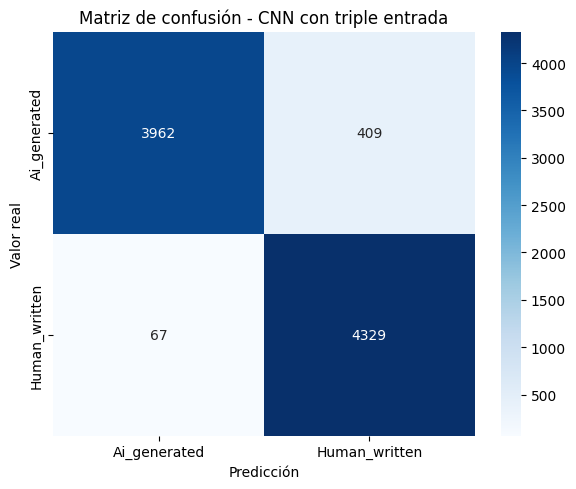

In [42]:
# ================================================================
# CELDA 2 – MODELO C-CNN MEJORADO (GLOBAL MAX POOLING)
# AHORA CON TRIPLE ENTRADA: secuencia sintáctica + código original + COMENTARIOS
# ================================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras.backend as K

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------------------------
# 2.1 Carga de los conjuntos generados en la Celda 1
# -----------------------------------------------
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Mapeo inverso (asumimos el orden ['cpp', 'C#', 'C'] que daba unique())
lang_inv = {0: 'cpp', 1: 'C#', 2: 'c'}   # ¡ajusta según tu `replace`!
train_df['lang'] = train_df['language_name'].map(lang_inv)
test_df['lang']  = test_df['language_name'].map(lang_inv)

# Generar secuencias sintácticas (suponiendo que get_syntactic_sequence ya existe)
train_df['syn_seq'] = train_df.apply(lambda r: get_syntactic_sequence(r['code'], r['lang']), axis=1)
test_df['syn_seq']  = test_df.apply(lambda r: get_syntactic_sequence(r['code'], r['lang']), axis=1)

print(train_df[['code', 'language_name', 'syn_seq']].head())

# ============================================================
# EXTRAEMOS LAS TRES FUENTES DE TEXTO
# ============================================================
X_train_syn_raw      = train_df['syn_seq'].astype(str).tolist()
X_train_code_raw     = train_df['code'].astype(str).tolist()
X_train_comments_raw = train_df['comments'].astype(str).tolist()   # <<< NUEVO

X_test_syn_raw      = test_df['syn_seq'].astype(str).tolist()
X_test_code_raw     = test_df['code'].astype(str).tolist()
X_test_comments_raw = test_df['comments'].astype(str).tolist()     # <<< NUEVO

y_train = train_df['target'].values
y_test = test_df['target'].values

print(f"Muestras de entrenamiento: {len(X_train_syn_raw)}")
print(f"Muestras de test: {len(X_test_syn_raw)}")
print(f"Clases: {np.unique(y_train)}")

# -----------------------------------------------
# 2.2 Tokenización y padding POR SEPARADO para cada entrada
# -----------------------------------------------
MAX_WORDS_SYN      = 10000
MAX_WORDS_CODE     = 10000
MAX_WORDS_COMMENTS = 500   # <<< NUEVO

MAX_LEN_SYN       = 500
MAX_LEN_CODE      = 1000
MAX_LEN_COMMENTS  = 500      # <<< NUEVO (ajusta si lo necesitas)

# Tokenizer para secuencias sintácticas
tokenizer_syn = Tokenizer(num_words=MAX_WORDS_SYN, oov_token='<OOV>')
tokenizer_syn.fit_on_texts(X_train_syn_raw)

X_train_syn_seq = tokenizer_syn.texts_to_sequences(X_train_syn_raw)
X_test_syn_seq  = tokenizer_syn.texts_to_sequences(X_test_syn_raw)

X_train_syn_pad = pad_sequences(X_train_syn_seq, maxlen=MAX_LEN_SYN, padding='post', truncating='post')
X_test_syn_pad  = pad_sequences(X_test_syn_seq, maxlen=MAX_LEN_SYN, padding='post', truncating='post')

# Tokenizer para código original
tokenizer_code = Tokenizer(num_words=MAX_WORDS_CODE, oov_token='<OOV>')
tokenizer_code.fit_on_texts(X_train_code_raw)

X_train_code_seq = tokenizer_code.texts_to_sequences(X_train_code_raw)
X_test_code_seq  = tokenizer_code.texts_to_sequences(X_test_code_raw)

X_train_code_pad = pad_sequences(X_train_code_seq, maxlen=MAX_LEN_CODE, padding='post', truncating='post')
X_test_code_pad  = pad_sequences(X_test_code_seq, maxlen=MAX_LEN_CODE, padding='post', truncating='post')

# Tokenizer para comentarios  <<< NUEVO
tokenizer_comments = Tokenizer(num_words=MAX_WORDS_COMMENTS, oov_token='<OOV>')
tokenizer_comments.fit_on_texts(X_train_comments_raw)

X_train_comments_seq = tokenizer_comments.texts_to_sequences(X_train_comments_raw)
X_test_comments_seq  = tokenizer_comments.texts_to_sequences(X_test_comments_raw)

X_train_comments_pad = pad_sequences(X_train_comments_seq, maxlen=MAX_LEN_COMMENTS, padding='post', truncating='post')
X_test_comments_pad  = pad_sequences(X_test_comments_seq, maxlen=MAX_LEN_COMMENTS, padding='post', truncating='post')

num_classes = len(np.unique(y_train))
print(f"Forma syn train: {X_train_syn_pad.shape}, code train: {X_train_code_pad.shape}, comments train: {X_train_comments_pad.shape}")
print(f"Clases: {num_classes}")

# -----------------------------------------------
# 2.3 Definición del modelo CON TRIPLE ENTRADA
# -----------------------------------------------
def build_triple_input_cnn(vocab_size_syn,
                          vocab_size_code,
                          vocab_size_comments,       # <<< NUEVO
                          embedding_dim=256,
                          max_len_syn=MAX_LEN_SYN,
                          max_len_code=MAX_LEN_CODE,
                          max_len_comments=MAX_LEN_COMMENTS,   # <<< NUEVO
                          num_classes=num_classes,
                          filter_sizes=(3, 4, 5),
                          num_filters=128,
                          dropout_rate=0.5,
                          l2_strength=0.001):

    # ---- Rama para secuencia sintáctica ----
    input_syn = layers.Input(shape=(max_len_syn,), dtype='int32', name='input_syn')
    embedding_syn = layers.Embedding(input_dim=vocab_size_syn,
                                     output_dim=embedding_dim,
                                     mask_zero=False,
                                     name='embedding_syn')(input_syn)

    # ---- Rama para código original ----
    input_code = layers.Input(shape=(max_len_code,), dtype='int32', name='input_code')
    embedding_code = layers.Embedding(input_dim=vocab_size_code,
                                      output_dim=embedding_dim,
                                      mask_zero=False,
                                      name='embedding_code')(input_code)

    # ---- Rama para comentarios ----   <<< NUEVO
    input_comments = layers.Input(shape=(max_len_comments,), dtype='int32', name='input_comments')
    embedding_comments = layers.Embedding(input_dim=vocab_size_comments,
                                          output_dim=embedding_dim,
                                          mask_zero=False,
                                          name='embedding_comments')(input_comments)

    l2_reg = regularizers.l2(l2_strength)
    conv_branches = []

    # Aplicamos convoluciones iguales a LAS TRES ramas
    for f_size in filter_sizes:
        # Rama sintáctica
        conv_syn = layers.Conv1D(filters=num_filters,
                                 kernel_size=f_size,
                                 strides=1,
                                 padding='valid',
                                 activation='relu',
                                 kernel_regularizer=l2_reg,
                                 bias_regularizer=l2_reg,
                                 name=f'conv_syn_{f_size}')(embedding_syn)
        pool_syn = layers.GlobalMaxPooling1D(name=f'global_maxpool_syn_{f_size}')(conv_syn)

        # Rama código original
        conv_code = layers.Conv1D(filters=num_filters,
                                  kernel_size=f_size,
                                  strides=1,
                                  padding='valid',
                                  activation='relu',
                                  kernel_regularizer=l2_reg,
                                  bias_regularizer=l2_reg,
                                  name=f'conv_code_{f_size}')(embedding_code)
        pool_code = layers.GlobalMaxPooling1D(name=f'global_maxpool_code_{f_size}')(conv_code)

        # Rama comentarios   <<< NUEVO
        conv_com = layers.Conv1D(filters=num_filters,
                                 kernel_size=f_size,
                                 strides=1,
                                 padding='valid',
                                 activation='relu',
                                 kernel_regularizer=l2_reg,
                                 bias_regularizer=l2_reg,
                                 name=f'conv_comments_{f_size}')(embedding_comments)
        pool_com = layers.GlobalMaxPooling1D(name=f'global_maxpool_comments_{f_size}')(conv_com)

        conv_branches.append(pool_syn)
        conv_branches.append(pool_code)
        conv_branches.append(pool_com)   # <<< NUEVO

    # Concatenamos todas las salidas de las convoluciones
    concatenated = layers.Concatenate(name='concatenate_all')(conv_branches)

    # Dropout
    dropout = layers.Dropout(rate=dropout_rate, name='dropout')(concatenated)

    # Capa oculta pequeña
    dense = layers.Dense(64,
                         activation='relu',
                         kernel_regularizer=l2_reg,
                         bias_regularizer=l2_reg,
                         name='dense_hidden')(dropout)

    # Salida
    outputs = layers.Dense(num_classes,
                           activation='softmax',
                           kernel_regularizer=l2_reg,
                           bias_regularizer=l2_reg,
                           name='output')(dense)

    model = models.Model(inputs=[input_syn, input_code, input_comments], outputs=outputs, name='Triple_Input_CNN')   # <<< NUEVO (tres inputs)
    return model

# Construir el modelo con los vocabularios respectivos
vocab_size_syn      = min(MAX_WORDS_SYN, len(tokenizer_syn.word_index) + 1)
vocab_size_code     = min(MAX_WORDS_CODE, len(tokenizer_code.word_index) + 1)
vocab_size_comments = min(MAX_WORDS_COMMENTS, len(tokenizer_comments.word_index) + 1)   # <<< NUEVO

model = build_triple_input_cnn(vocab_size_syn=vocab_size_syn,
                               vocab_size_code=vocab_size_code,
                               vocab_size_comments=vocab_size_comments,   # <<< NUEVO
                               embedding_dim=256,
                               max_len_syn=MAX_LEN_SYN,
                               max_len_code=MAX_LEN_CODE,
                               max_len_comments=MAX_LEN_COMMENTS,        # <<< NUEVO
                               num_classes=num_classes,
                               filter_sizes=(3, 4, 5),
                               num_filters=128,
                               dropout_rate=0.5,
                               l2_strength=0.001)

model.summary()

# Métricas personalizadas (las mismas que tenías)
def sparse_f1_score(y_true, y_pred):
    y_pred_classes = K.argmax(y_pred, axis=-1)
    y_true = K.cast(y_true, 'int64')
    
    def recall(y_t, y_p):
        tp = K.sum(K.round(K.clip(y_t * y_p, 0, 1)))
        positives = K.sum(K.round(K.clip(y_t, 0, 1)))
        return tp / (positives + K.epsilon())

    def precision(y_t, y_p):
        tp = K.sum(K.round(K.clip(y_t * y_p, 0, 1)))
        preds = K.sum(K.round(K.clip(y_p, 0, 1)))
        return tp / (preds + K.epsilon())

    y_true_oh = tf.one_hot(K.flatten(y_true), num_classes)
    y_pred_oh = tf.one_hot(y_pred_classes, num_classes)
    
    p = precision(y_true_oh, y_pred_oh)
    r = recall(y_true_oh, y_pred_oh)
    return 2 * ((p * r) / (p + r + K.epsilon()))

def sparse_recall(y_true, y_pred):
    y_pred_classes = K.argmax(y_pred, axis=-1)
    y_true = K.cast(y_true, 'int64')
    y_true_oh = tf.one_hot(K.flatten(y_true), num_classes)
    y_pred_oh = tf.one_hot(y_pred_classes, num_classes)
    
    tp = K.sum(K.round(K.clip(y_true_oh * y_pred_oh, 0, 1)))
    positives = K.sum(K.round(K.clip(y_true_oh, 0, 1)))
    return tp / (positives + K.epsilon())

# Compilación
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy', sparse_recall, sparse_f1_score])

# -----------------------------------------------
# 2.4 Entrenamiento con tres entradas
# -----------------------------------------------
BATCH_SIZE = 32
EPOCHS = 150

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

import os
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'triple_cnn_best.h5')

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

callbacks_list = [reduce_lr, checkpoint_cb]

print("\nIniciando entrenamiento del modelo con triple entrada...")
history = model.fit(
    [X_train_syn_pad, X_train_code_pad, X_train_comments_pad],   # <<< TRES ARRAYS
    y_train,
    validation_split=0.2,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

# -----------------------------------------------
# 2.5 Evaluación final (con triple entrada)
# -----------------------------------------------
print("\nEvaluación en conjunto de test:")
eval_results = model.evaluate(
    [X_test_syn_pad, X_test_code_pad, X_test_comments_pad], y_test, verbose=1   # <<< TRES ARRAYS
)
test_loss = eval_results[0]
test_acc = eval_results[1]
# Si quieres también recuperar las métricas personalizadas:
# test_recall = eval_results[2]
# test_f1 = eval_results[3]
# print(f"Recall: {test_recall:.4f}, F1: {test_f1:.4f}")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict([X_test_syn_pad, X_test_code_pad, X_test_comments_pad])  # <<< TRES
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Ai_generated', 'Human_written']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ai_generated', 'Human_written'],
            yticklabels=['Ai_generated', 'Human_written'])
plt.title('Matriz de confusión - CNN con triple entrada')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.savefig('confusion_matrix_triple_input.png', dpi=150)
plt.show()

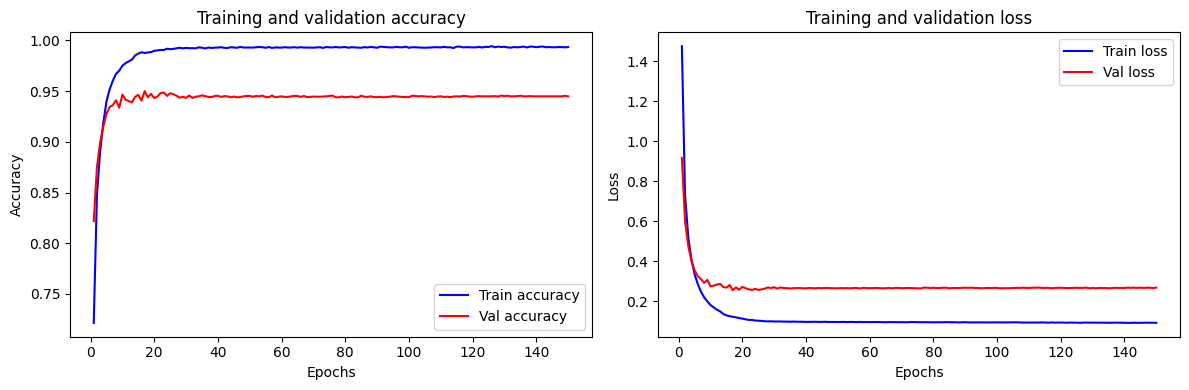

In [44]:
history_head = history
acc = history_head.history['accuracy']
val_acc = history_head.history['val_accuracy']
loss = history_head.history['loss']
val_loss = history_head.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Train accuracy')
plt.plot(epochs, val_acc, 'r-', label='Val accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Train loss')
plt.plot(epochs, val_loss, 'r-', label='Val loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

274/274 [==============================] - 6s 20ms/step - loss: 0.2385 - accuracy: 0.9499
Test Loss: 0.2385
Test Accuracy: 0.9499
274/274 [==============================] - 5s 17ms/step

Informe de clasificación:
               precision    recall  f1-score   support

 Ai_generated       0.98      0.92      0.95      4371
Human_written       0.92      0.98      0.95      4396

     accuracy                           0.95      8767
    macro avg       0.95      0.95      0.95      8767
 weighted avg       0.95      0.95      0.95      8767



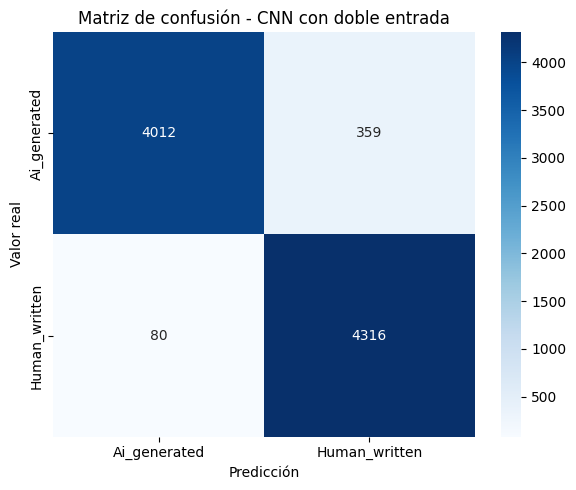

In [48]:
from tensorflow.keras.models import load_model

# Opción 1: Intentar cargar con compile=False (menos dependencias)
try:
    model = load_model('./checkpoints/triple_cnn_best.h5', compile=False)
except Exception as e:
    print("Carga directa falló, reconstruyendo arquitectura...")
    # Opción 2: Reconstruir el modelo exactamente igual y cargar los pesos
    # Asegúrate de que vocab_size_syn, vocab_size_code, MAX_LEN_SYN, MAX_LEN_CODE estén definidos
    model = build_triple_input_cnn(vocab_size_syn=vocab_size_syn,
                                 vocab_size_code=vocab_size_code,
                                 embedding_dim=256,
                                 max_len_syn=MAX_LEN_SYN,
                                 max_len_code=MAX_LEN_CODE,
                                 num_classes=num_classes,
                                 filter_sizes=(3, 4, 5),
                                 num_filters=128,
                                 dropout_rate=0.5,
                                 l2_strength=0.001)
    model.load_weights('./checkpoints/dual_cnn_best.h5')   # el .h5 contiene también los pesos

# Compilamos (necesario si se cargó con compile=False)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Evaluación (esto ya estaba bien)
eval_results = model.evaluate(
    [X_test_syn_pad, X_test_code_pad, X_test_comments_pad], y_test, verbose=1
)
test_loss = eval_results[0]
test_acc = eval_results[1]
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# ===== CORRECCIÓN EN LA PREDICCIÓN =====
# El modelo espera tres entradas: [secuencias sintácticas, código original, comentarios]
y_pred_probs = model.predict([X_test_syn_pad, X_test_code_pad, X_test_comments_pad])   # ← lista con tres arrays
y_pred = np.argmax(y_pred_probs, axis=1)

# A partir de aquí todo igual:
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Ai_generated', 'Human_written']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ai_generated', 'Human_written'],
            yticklabels=['Ai_generated', 'Human_written'])
plt.title('Matriz de confusión - CNN con doble entrada')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.savefig('confusion_matrix_dual_input.png', dpi=150)
plt.show()